<a href="https://colab.research.google.com/github/eternitvy/PCVK_26/blob/main/PCVK_JS05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Regita Abelia Putri Satriyo'
NIM = '244107020173'
N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

BASE = f'/content/drive/MyDrive/AAPCVK/{NIM}'
CONTOH = '/content/drive/MyDrive/AAPCVK'

import matplotlib.pyplot as plt

def set_title_wajib():
    plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']), fontsize=9)

NAMA : Regita Abelia Putri Satriyo
NIM : 244107020173 | N = 173
bins   : 16
clip   : 2.5
tile   : 3
L      : 8
WAKTU : 2026-09-30 21:27:15 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : a465a7b0942c0e2d


# **PERCOBAAN PARKTIKUM E1**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import glob
import math
import os
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
from skimage import io

<BarContainer object of 256 artists>

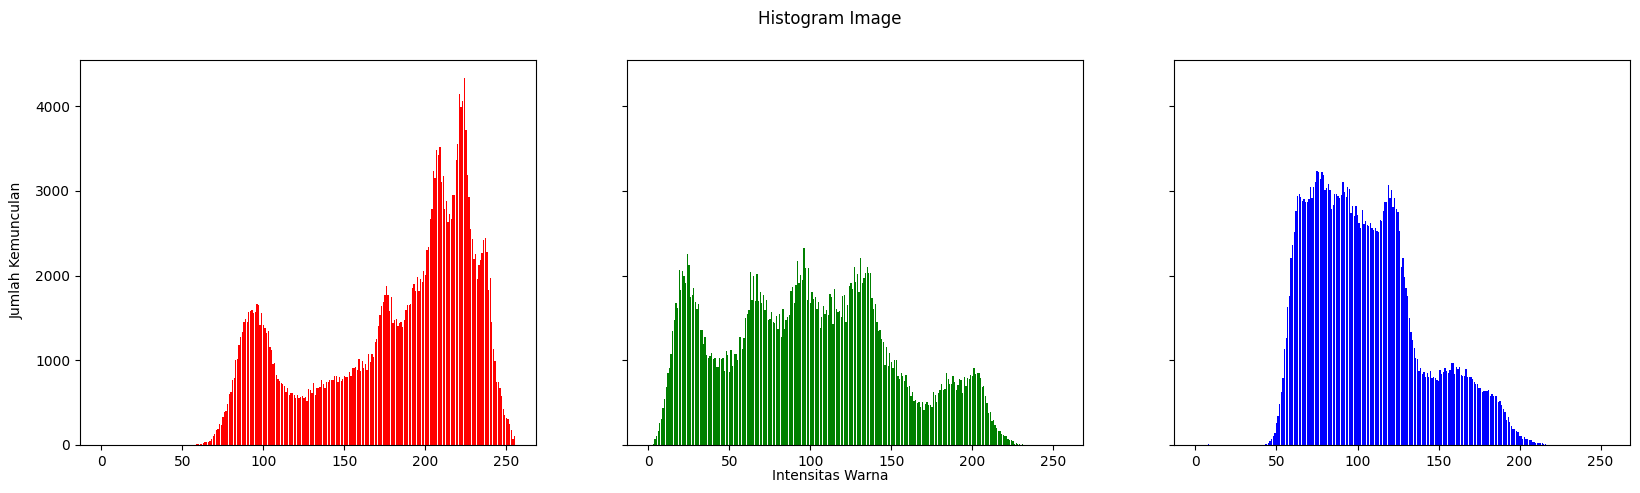

In [5]:
# Membuat histogramm image manual

img = cv.imread('/content/drive/MyDrive/AAPCVK/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
  for x in range(0, width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

name = np.arange(256)
fig, axs = plt.subplots(1,3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.suptitle('Histogram Image')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va = 'center', rotation = 'vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha = 'center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

PERTANYAAN PRAKTIKUM E1

=== Pembuktian Lenna.png ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0.0



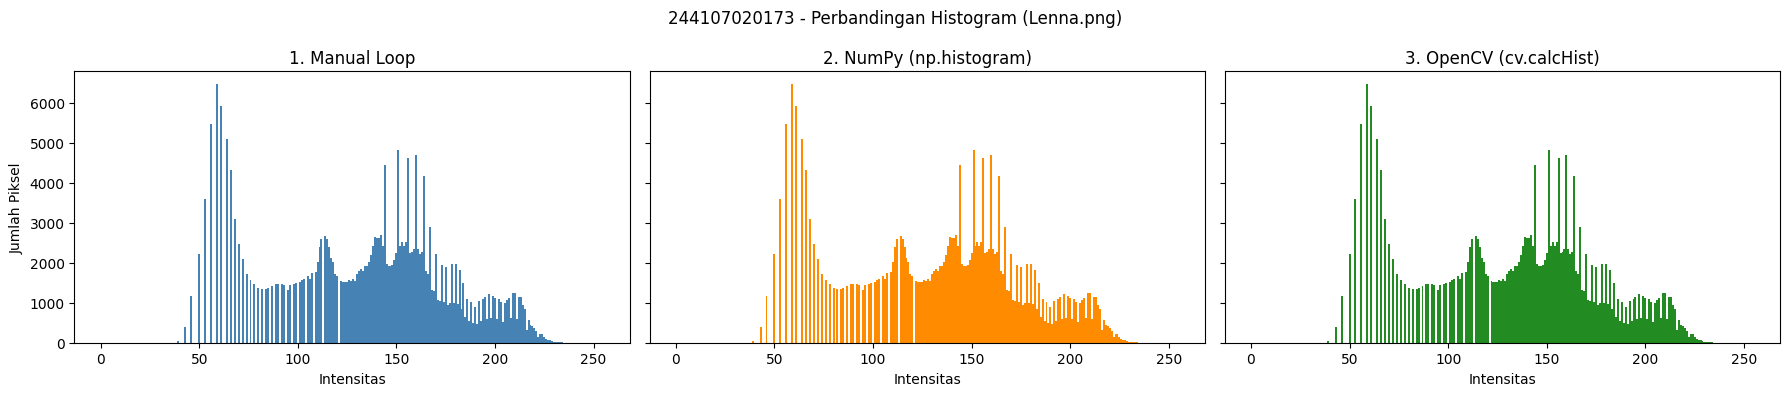

=== Pembuktian KTMlama.jpg ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0.0



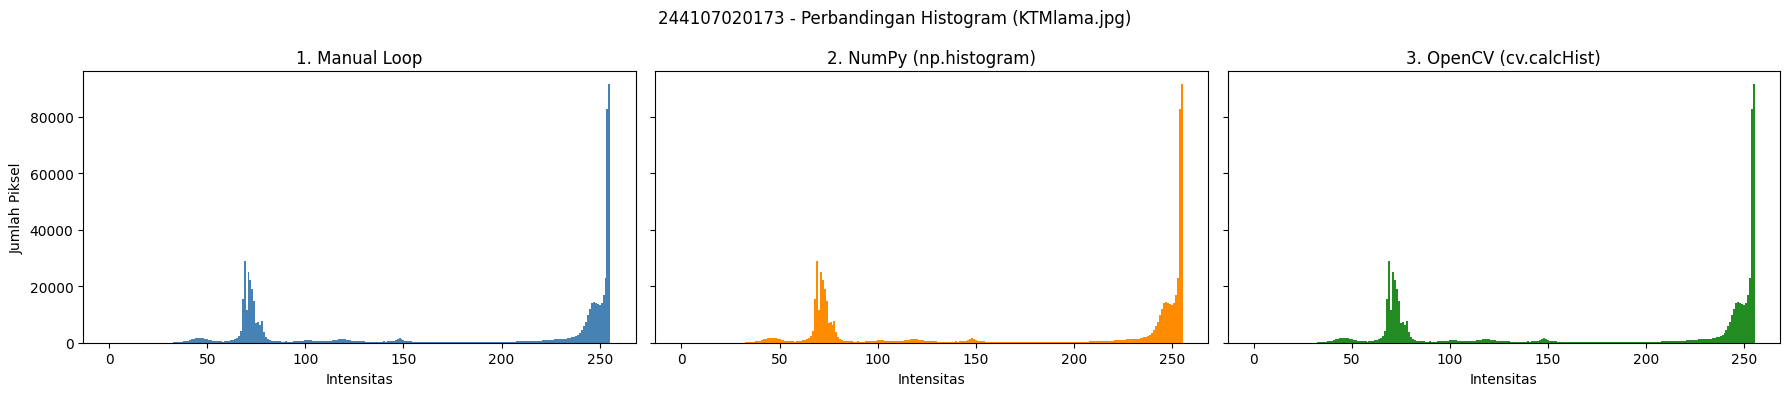

In [6]:
# NO 1 - Membuat histogram citra menggunakan library numpy dan openCV

def bandingkan_histogram(img_gray, title_prefix=''):
  # Perhitungan Manual Loop
  h_manual = np.zeros(256, dtype=np.int64)
  for y in range(img_gray.shape[0]):
    for x in range(img_gray.shape[1]):
      h_manual[img_gray[y, x]] += 1

  # Perhitungan NumPy
  h_numpy, _ = np.histogram(img_gray.ravel(), bins=256, range=[0, 256])

  # Perhitungan OpenCV
  h_cv = cv.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()

  # Hitung Selisih
  diff_manual_numpy = np.max(np.abs(h_manual - h_numpy))
  diff_manual_cv = np.max(np.abs(h_manual - h_cv))

  print(f'=== Pembuktian {title_prefix} ===')
  print(f'Selisih Maksimum (Manual vs NumPy) : {diff_manual_numpy}')
  print(f'Selisih Maksimum (Manual vs OpenCV): {diff_manual_cv}\n')

  # Visualisasi Plot Histogram
  fig, axs = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)
  fig.suptitle(
      f'{NIM} - Perbandingan Histogram ({title_prefix})', fontsize=12
  )

  axs[0].bar(np.arange(256), h_manual, color='steelblue', width=1.0)
  axs[0].set_title('1. Manual Loop')
  axs[0].set_xlabel('Intensitas')
  axs[0].set_ylabel('Jumlah Piksel')

  axs[1].bar(np.arange(256), h_numpy, color='darkorange', width=1.0)
  axs[1].set_title('2. NumPy (np.histogram)')
  axs[1].set_xlabel('Intensitas')

  axs[2].bar(np.arange(256), h_cv, color='forestgreen', width=1.0)
  axs[2].set_title('3. OpenCV (cv.calcHist)')
  axs[2].set_xlabel('Intensitas')

  plt.tight_layout()
  plt.show()


# Uji pada Lenna.png
lena_path = os.path.join(CONTOH, 'Lenna.png')
if os.path.exists(lena_path):
  lena_gray = cv.imread(lena_path, cv.IMREAD_GRAYSCALE)
  bandingkan_histogram(lena_gray, 'Lenna.png')
else:
  print(f'File {lena_path} tidak ditemukan.')

# Uji pada KTMlama.jpg
ktm_path = os.path.join(BASE, 'KTMlama.jpg')
if os.path.exists(ktm_path):
  ktm_gray = cv.imread(ktm_path, cv.IMREAD_GRAYSCALE)
  bandingkan_histogram(ktm_gray, 'KTMlama.jpg')
else:
  print(f'File {ktm_path} tidak ditemukan.')

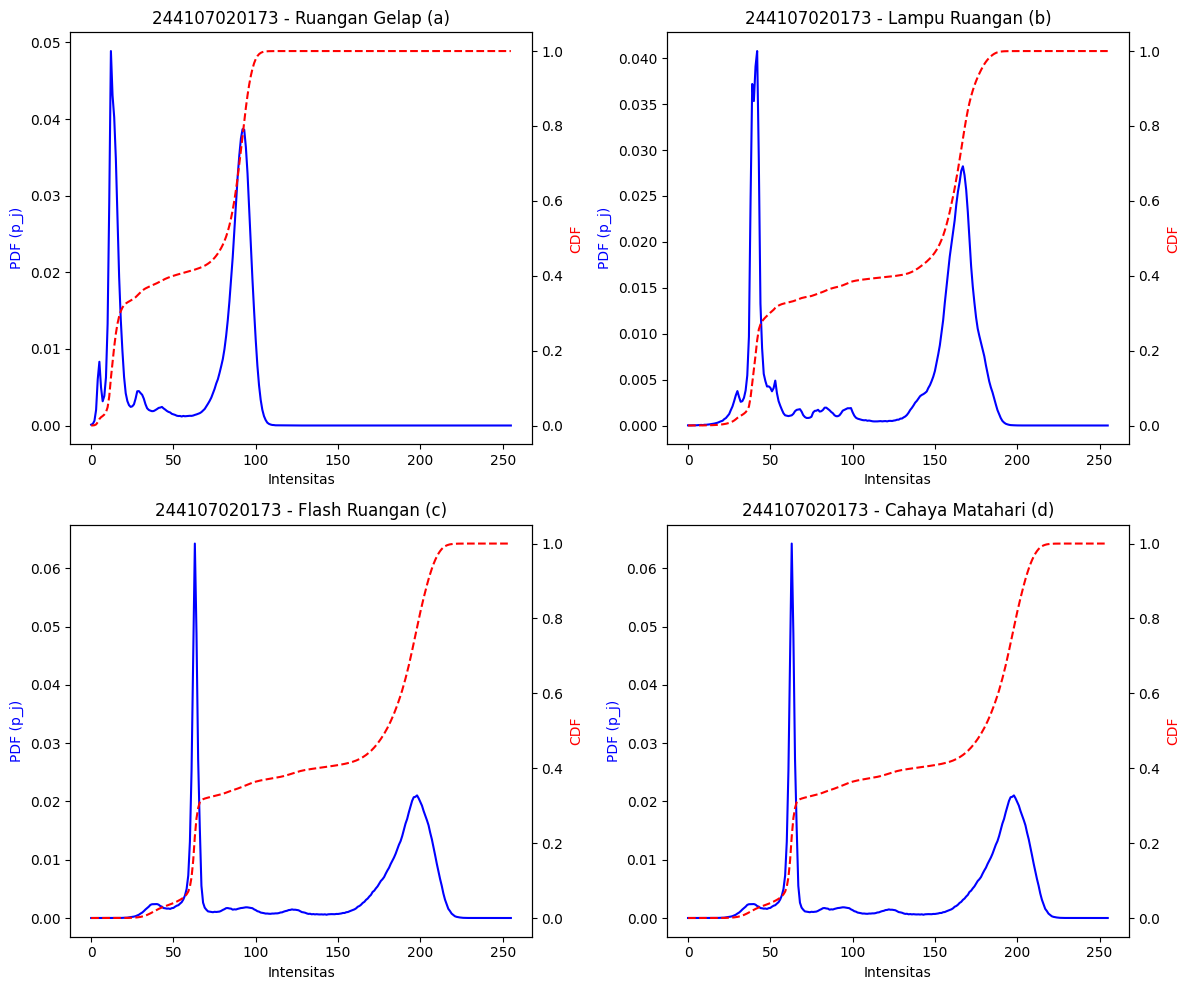

In [9]:
# NO 2 - Menggambarkan histogram ternormalisasi

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
files = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']
titles = [
    'Ruangan Gelap (a)',
    'Lampu Ruangan (b)',
    'Flash Ruangan (c)',
    'Cahaya Matahari (d)',
]

for idx, fname in enumerate(files):
  fpath = os.path.join(BASE, fname)
  ax = axs[idx // 2, idx % 2]
  if os.path.exists(fpath):
    img_g = cv.imread(fpath, cv.IMREAD_GRAYSCALE)
    p_j = cv.calcHist([img_g], [0], None, [256], [0, 256]).flatten() / img_g.size
    cdf = np.cumsum(p_j)

    ax.plot(p_j, color='blue', label='Histogram p(j)')
    ax2 = ax.twinx()
    ax2.plot(cdf, color='red', linestyle='--', label='CDF')
    ax.set_title(f'{NIM} - {titles[idx]}')
    ax.set_xlabel('Intensitas')
    ax.set_ylabel('PDF (p_j)', color='blue')
    ax2.set_ylabel('CDF', color='red')
plt.tight_layout()
plt.show()

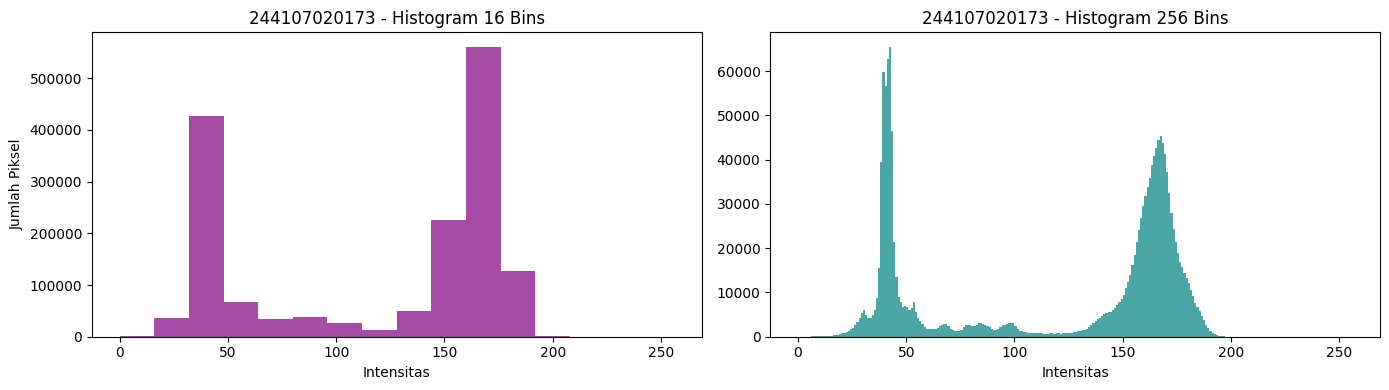

In [12]:
# Mengulangi histogram KTB1b dengan jumlah bin sebesar PARAM[‘bins’] dan dengan 256 bin

fpath_jpg = os.path.join(BASE, 'KTM1b.jpg')
fpath_jpeg = os.path.join(BASE, 'KTM1b.jpeg')

if os.path.exists(fpath_jpg):
  fpath = fpath_jpg
elif os.path.exists(fpath_jpeg):
  fpath = fpath_jpeg
else:
  fpath = None

if fpath:
  ktm_g = cv.imread(fpath, cv.IMREAD_GRAYSCALE)
  fig, axs = plt.subplots(1, 2, figsize=(14, 4))

  axs[0].hist(
      ktm_g.ravel(),
      bins=PARAM['bins'],
      range=[0, 256],
      color='purple',
      alpha=0.7,
  )
  axs[0].set_title(f"{NIM} - Histogram {PARAM['bins']} Bins")
  axs[0].set_xlabel('Intensitas')
  axs[0].set_ylabel('Jumlah Piksel')

  # Histogram dengan 256 bin
  axs[1].hist(
      ktm_g.ravel(), bins=256, range=[0, 256], color='teal', alpha=0.7
  )
  axs[1].set_title(f'{NIM} - Histogram 256 Bins')
  axs[1].set_xlabel('Intensitas')

  plt.tight_layout()
  plt.show()
else:
  print(f'File KTM1b (.jpg/.jpeg) TIDAK DITEMUKAN di lokasi: {BASE}')

Ketika jumlah bin dikurangi (misal dari 256 ke 8/16/32/64 bin), informasi detail variasi gradasi/intensitas halus (fine-grained intensity transitions) akan hilang. Beberapa puncak kecil (peaks) dan lembah (valleys) pada grafik teragregasi/tergabung ke dalam satu rentang bin yang luas, sehingga distribusi lokal tidak terwakili dengan detail.

# **PERCOBAAN PRAKTIKUM E2**

In [21]:
# Helper: Memeriksa dan mendapatkan path file (.jpg atau .jpeg)
def get_valid_path(base_dir, filename_no_ext):
  fpath_jpg = os.path.join(base_dir, f'{filename_no_ext}.jpg')
  fpath_jpeg = os.path.join(base_dir, f'{filename_no_ext}.jpeg')
  if os.path.exists(fpath_jpg):
    return fpath_jpg
  elif os.path.exists(fpath_jpeg):
    return fpath_jpeg
  return None


# Helper: Menghitung Pergeseran Hue
def geser_hue(asli, hasil):
  h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  d = np.abs(h1 - h2)
  d = np.minimum(d, 180 - d)  # Rentang Hue OpenCV: 0-179
  return d.mean()


# Helper: Menghitung PSNR
def hitung_psnr(original, processed):
  mse = np.mean((original.astype(np.float64) - processed.astype(np.float64)) ** 2)
  if mse == 0:
    return float('inf')
  return 20 * np.log10(255.0 / np.sqrt(mse))

Uji Lena LC -> Selisih Maksimum HE Manual vs OpenCV: 0


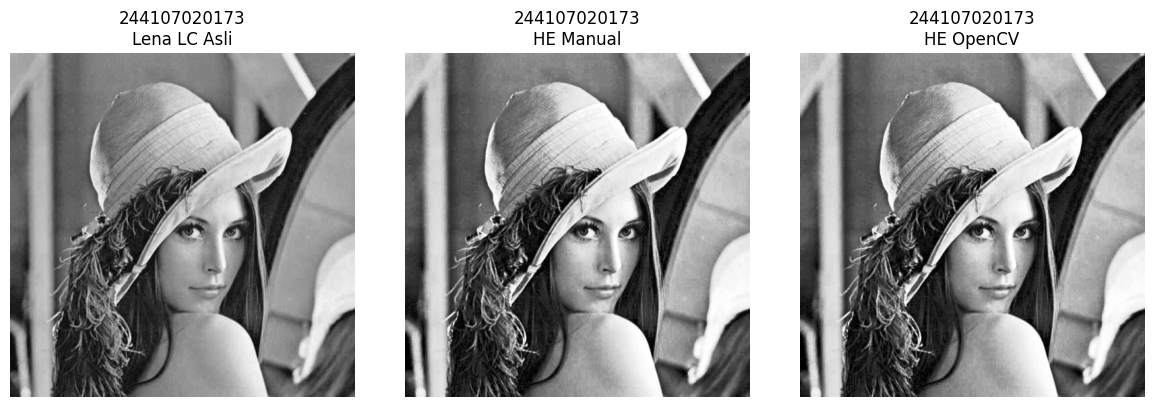

Uji KTM1a (Gelap) -> Selisih Maksimum HE Manual vs OpenCV: 1


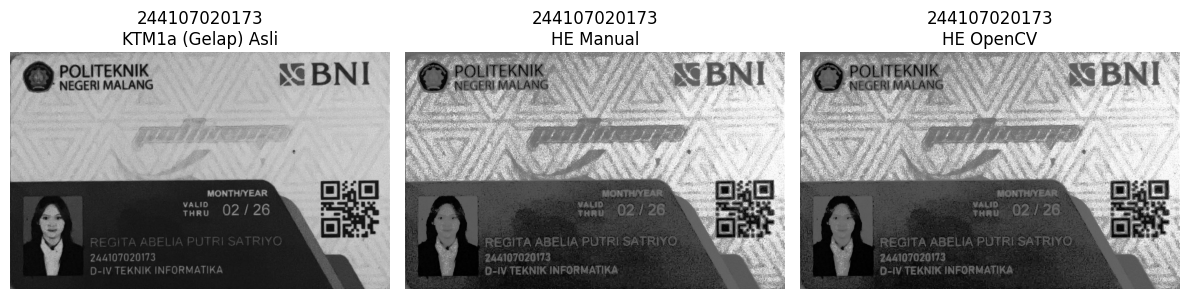

In [22]:
def he_manual(img_gray):
  H, W = img_gray.shape
  MN = H * W
  h = np.zeros(256, dtype=np.int64)
  for y in range(H):
    for x in range(W):
      h[img_gray[y, x]] += 1
  cdf = np.cumsum(h)
  sk = np.round((255 * cdf) / MN).astype(np.uint8)
  return sk[img_gray]


# List sampel yang diuji
uji_files = [
    (CONTOH, 'lena_lc', 'Lena LC'),
    (BASE, 'KTM1a', 'KTM1a (Gelap)'),
]

for base_dir, f_name, label in uji_files:
  fpath = get_valid_path(base_dir, f_name)
  if fpath:
    img = cv.imread(fpath, cv.IMREAD_GRAYSCALE)
    res_manual = he_manual(img)
    res_cv = cv.equalizeHist(img)

    diff = np.max(np.abs(res_manual.astype(int) - res_cv.astype(int)))
    print(f'Uji {label} -> Selisih Maksimum HE Manual vs OpenCV: {diff}')

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img, cmap='gray')
    axs[0].set_title(f'{NIM}\n{label} Asli')
    axs[1].imshow(res_manual, cmap='gray')
    axs[1].set_title(f'{NIM}\nHE Manual')
    axs[2].imshow(res_cv, cmap='gray')
    axs[2].set_title(f'{NIM}\nHE OpenCV')
    for ax in axs:
      ax.axis('off')
    plt.tight_layout()
    plt.show()
  else:
    print(f'File {f_name} tidak ditemukan.')

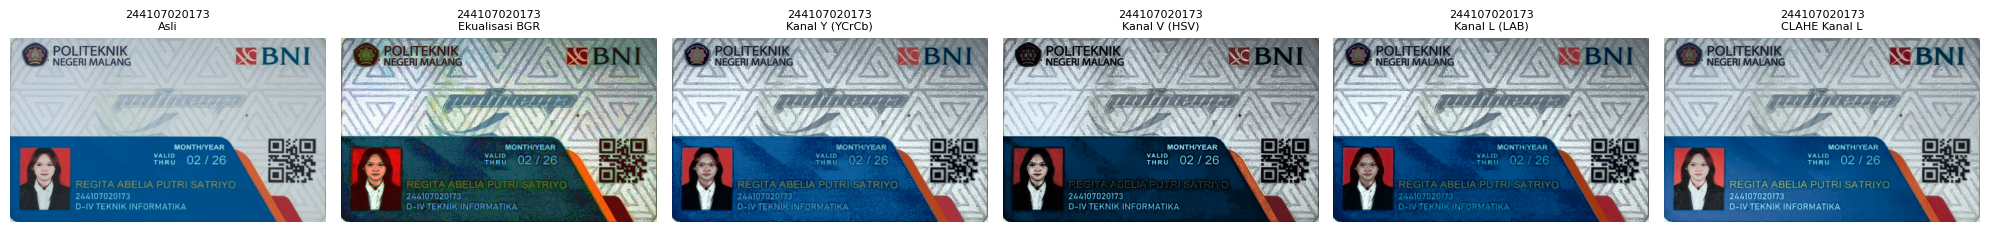

Metode/Kanal         | Pergeseran Hue (°)   | Rerata Kecerahan
------------------------------------------------------------
Asli                 | 0.00                 | 142.63         
Ekualisasi BGR       | 40.97                | 125.45         
Kanal Y (YCrCb)      | 1.62                 | 131.04         
Kanal V (HSV)        | 1.89                 | 112.70         
Kanal L (LAB)        | 3.51                 | 121.84         
CLAHE Kanal L        | 2.05                 | 134.15         


In [23]:
ktm_d_path = get_valid_path(BASE, 'KTM1d')

if ktm_d_path:
  bgr = cv.imread(ktm_d_path)

  # 1. B, G, R Terpisah
  chans = list(cv.split(bgr))
  for i in range(3):
    chans[i] = cv.equalizeHist(chans[i])
  he_rgb = cv.merge(chans)

  # 2. Kanal Y (YCrCb)
  ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
  y, cr, cb = cv.split(ycrcb)
  he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

  # 3. Kanal V (HSV)
  hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
  h_ch, s_ch, v_ch = cv.split(hsv)
  he_v = cv.cvtColor(
      cv.merge([h_ch, s_ch, cv.equalizeHist(v_ch)]), cv.COLOR_HSV2BGR
  )

  # 4. Kanal L (LAB)
  lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
  l_ch, a_ch, b_ch = cv.split(lab)
  he_l = cv.cvtColor(
      cv.merge([cv.equalizeHist(l_ch), a_ch, b_ch]), cv.COLOR_LAB2BGR
  )

  # 5. CLAHE Kanal L
  clahe = cv.createCLAHE(
      clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile'])
  )
  he_clahe = cv.cvtColor(
      cv.merge([clahe.apply(l_ch), a_ch, b_ch]), cv.COLOR_LAB2BGR
  )

  judul = [
      'Asli',
      'Ekualisasi BGR',
      'Kanal Y (YCrCb)',
      'Kanal V (HSV)',
      'Kanal L (LAB)',
      'CLAHE Kanal L',
  ]
  citra = [bgr, he_rgb, he_y, he_v, he_l, he_clahe]

  fig, axs = plt.subplots(1, 6, figsize=(20, 4))
  for idx, (c, t) in enumerate(zip(citra, judul)):
    axs[idx].imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    axs[idx].set_title(f'{NIM}\n{t}', fontsize=8)
    axs[idx].axis('off')
  plt.tight_layout()
  plt.show()

  # Cetak Hasil Analisis
  print(
      f"{'Metode/Kanal':<20} | {'Pergeseran Hue (°)':<20} | {'Rerata'}"
      ' Kecerahan'
  )
  print('-' * 60)
  for t, c in zip(judul, citra):
    g_hue = geser_hue(bgr, c) * 2
    r_terang = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    print(f'{t:<20} | {g_hue:<20.2f} | {r_terang:<15.2f}')
else:
  print('File KTM1d tidak ditemukan.')

--- TAHAP 2: Citra lena_lc.jpg ---


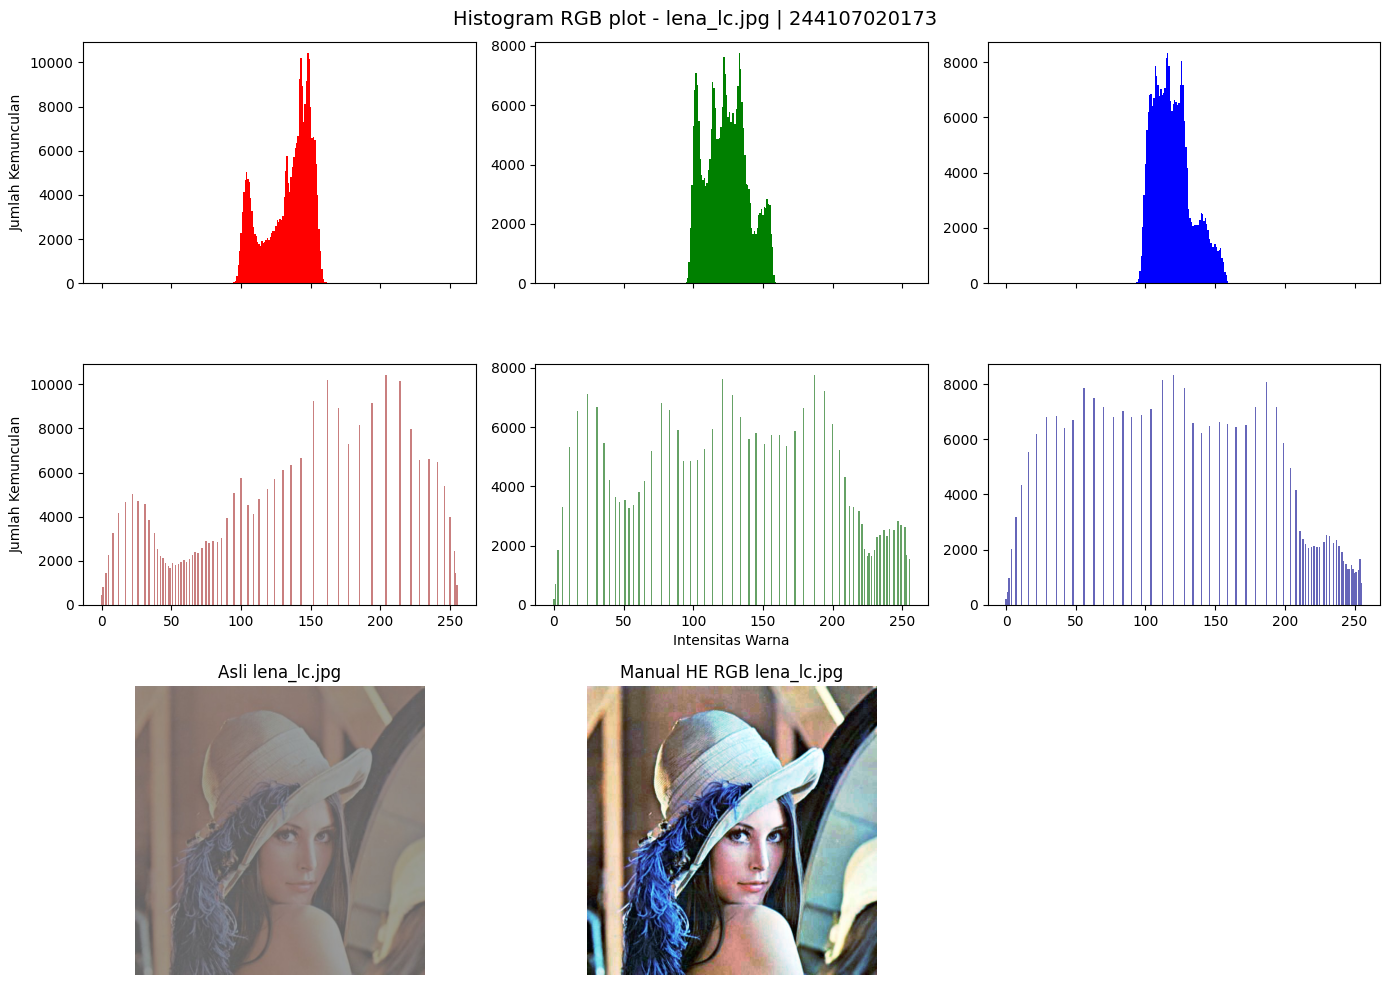

--- TAHAP 2: Citra KTP1a.jpg ---


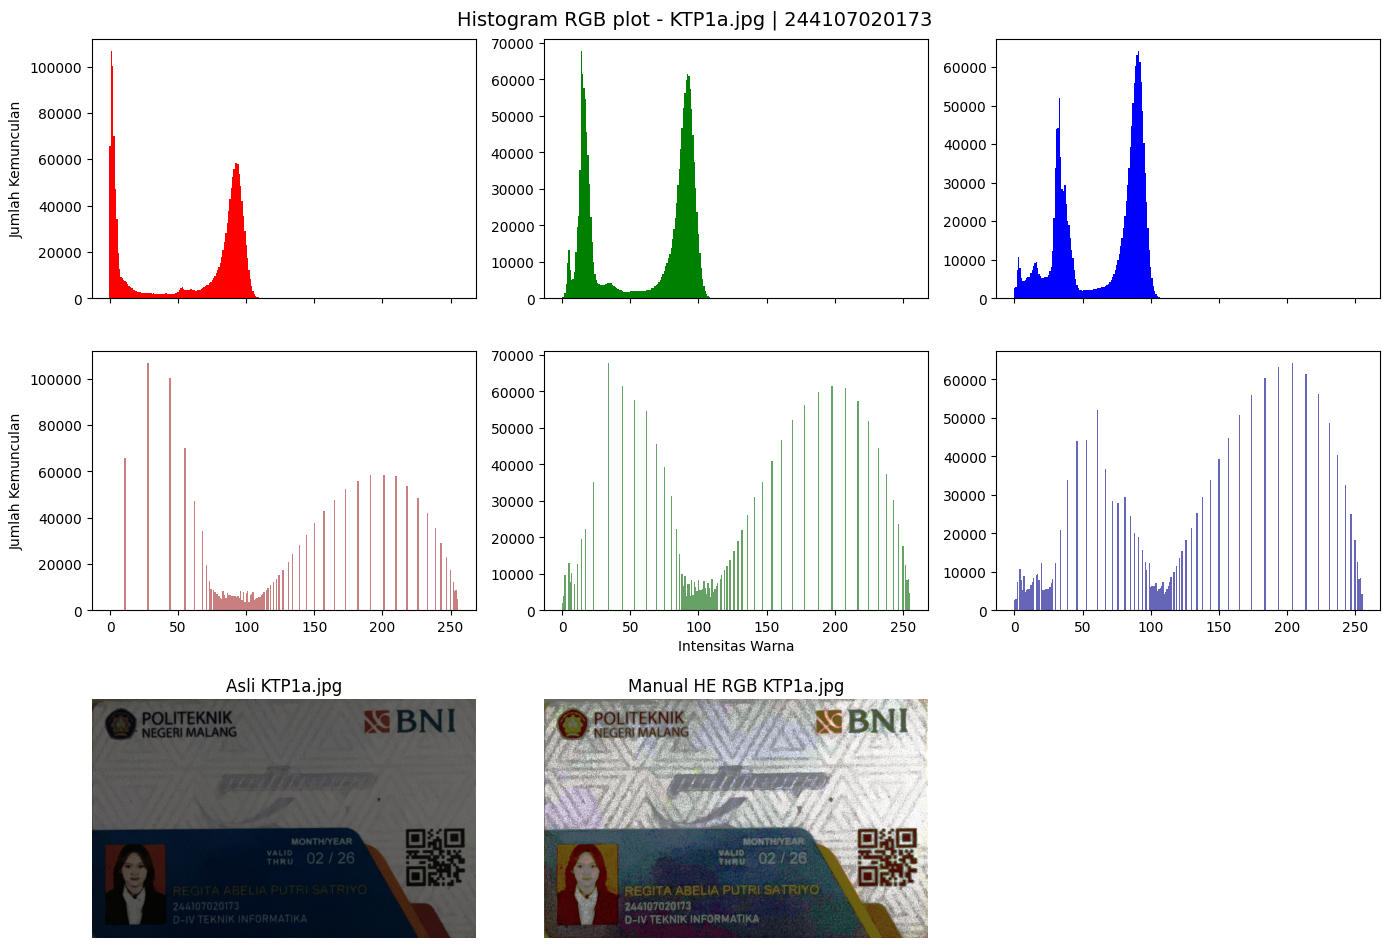

In [25]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

def manual_he_channel(channel):
  h = np.zeros(256, dtype=np.int64)
  H, W = channel.shape
  for y in range(H):
    for x in range(W):
      h[channel[y, x]] += 1

  cdf = np.cumsum(h)
  sk = np.round((255 * cdf) / (H * W)).astype(np.uint8)
  return sk[channel], h

def get_path(base_dir, filename_no_ext):
  p1 = os.path.join(base_dir, f'{filename_no_ext}.jpg')
  p2 = os.path.join(base_dir, f'{filename_no_ext}.jpeg')
  if os.path.exists(p1):
    return p1
  if os.path.exists(p2):
    return p2
  return None

daftar_uji = [
    (CONTOH, 'lena_lc', 'lena_lc.jpg'),
    (BASE, 'KTM1a', 'KTP1a.jpg'),
]

for base_folder, file_key, label_file in daftar_uji:
  img_path = get_path(base_folder, file_key)

  if img_path and os.path.exists(img_path):
    print(f'--- TAHAP 2: Citra {label_file} ---')

    # BGR ke RGB
    bgr = cv.imread(img_path)
    rgb_asli = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

    # Pisahkan Kanal R, G, B
    r_asli, g_asli, b_asli = (
        rgb_asli[:, :, 0],
        rgb_asli[:, :, 1],
        rgb_asli[:, :, 2],
    )

    # Ekualisasi per kanal secara manual
    r_he, h_r_asli = manual_he_channel(r_asli)
    g_he, h_g_asli = manual_he_channel(g_asli)
    b_he, h_b_asli = manual_he_channel(b_asli)

    rgb_he = cv.merge([r_he, g_he, b_he])

    # Hitung histogram hasil HE
    _, h_r_he = manual_he_channel(r_he)
    _, h_g_he = manual_he_channel(g_he)
    _, h_b_he = manual_he_channel(b_he)

    # ================= VISUALISASI =================
    fig = plt.figure(figsize=(14, 10))

    plt.suptitle(
        f'Histogram RGB plot - {label_file} | {NIM}',
        fontsize=14,
        y=0.98,
    )

    gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1.2])

    ax_r1 = fig.add_subplot(gs[0, 0])
    ax_r1.bar(range(256), h_r_asli, color='red', width=1.0)
    ax_r1.set_ylabel('Jumlah Kemunculan')
    ax_r1.set_xticklabels([])

    ax_g1 = fig.add_subplot(gs[0, 1])
    ax_g1.bar(range(256), h_g_asli, color='green', width=1.0)
    ax_g1.set_xticklabels([])

    ax_b1 = fig.add_subplot(gs[0, 2])
    ax_b1.bar(range(256), h_b_asli, color='blue', width=1.0)
    ax_b1.set_xticklabels([])

    ax_r2 = fig.add_subplot(gs[1, 0])
    ax_r2.bar(range(256), h_r_he, color='brown', alpha=0.6, width=1.0)
    ax_r2.set_ylabel('Jumlah Kemunculan')

    ax_g2 = fig.add_subplot(gs[1, 1])
    ax_g2.bar(range(256), h_g_he, color='darkgreen', alpha=0.6, width=1.0)
    ax_g2.set_xlabel('Intensitas Warna')

    ax_b2 = fig.add_subplot(gs[1, 2])
    ax_b2.bar(range(256), h_b_he, color='darkblue', alpha=0.6, width=1.0)

    ax_img1 = fig.add_subplot(gs[2, 0])
    ax_img1.imshow(rgb_asli)
    ax_img1.set_title(f'Asli {label_file}')
    ax_img1.axis('off')

    ax_img2 = fig.add_subplot(gs[2, 1])
    ax_img2.imshow(rgb_he)
    ax_img2.set_title(f'Manual HE RGB {label_file}')
    ax_img2.axis('off')

    plt.tight_layout()
    plt.show()
  else:
    print(f'File {label_file} tidak ditemukan.')

1. Pergeseran Hue Paling Besar: Cara Ekualisasi Kanal B, G, R terpisah. Hal ini disebabkan ekualisasi yang dilakukan independen pada tiap kanal merusak perbandingan rasio intensitas R:G:B asli, sehingga tone warna berubah drastis (color cast/discoloration).   
2. Mengapa Ekualisasi Kanal Terang Tidak Bergeser 0°?: Karena ketika kanal terang (Y,V, atau L) diekualisasi lalu dikonversi kembali ke ruang warna BGR, terjadi pemotongan (clipping/saturation) pada range [0,255] serta pembulatan diskrit (quantization/rounding errors). Hal ini membuat kombinasi BGR baru tidak menghasilkan Hue yang identik 100% secara sistemik.   

3. Pilihan Terbaik untuk KTM: Kanal L (Ruang Warna LAB) atau Kanal Y (YCrCb).   
- Alasan: Ruang warna LAB secara perseptual memisahkan kecerahan (L) dan kromatinsitas warna (a,b) secara independen tanpa mendistorsi warna alami pada latar belakang dan teks dokumen KTM.   
4. Penerapan CLAHE: CLAHE menghasilkan pergeseran Hue yang lebih rendah dan rerata kecerahan yang lebih stabil/alami dibandingkan ekualisasi global, karena kontras dinaikkan secara lokal tanpa mengalami over-saturation atau kontras berlebihan pada latar belakang.

PERTANYAAN PRAKTIKUM E2

PSNR Antara Citra Asli dan Hasil Ekualisasi HE: 9.87 dB


/tmp/ipykernel_543/1045784065.py:22: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(ktm_a.ravel(), 256, [0, 256])
/tmp/ipykernel_543/1045784065.py:24: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(ktm_a_he.ravel(), 256, [0, 256])


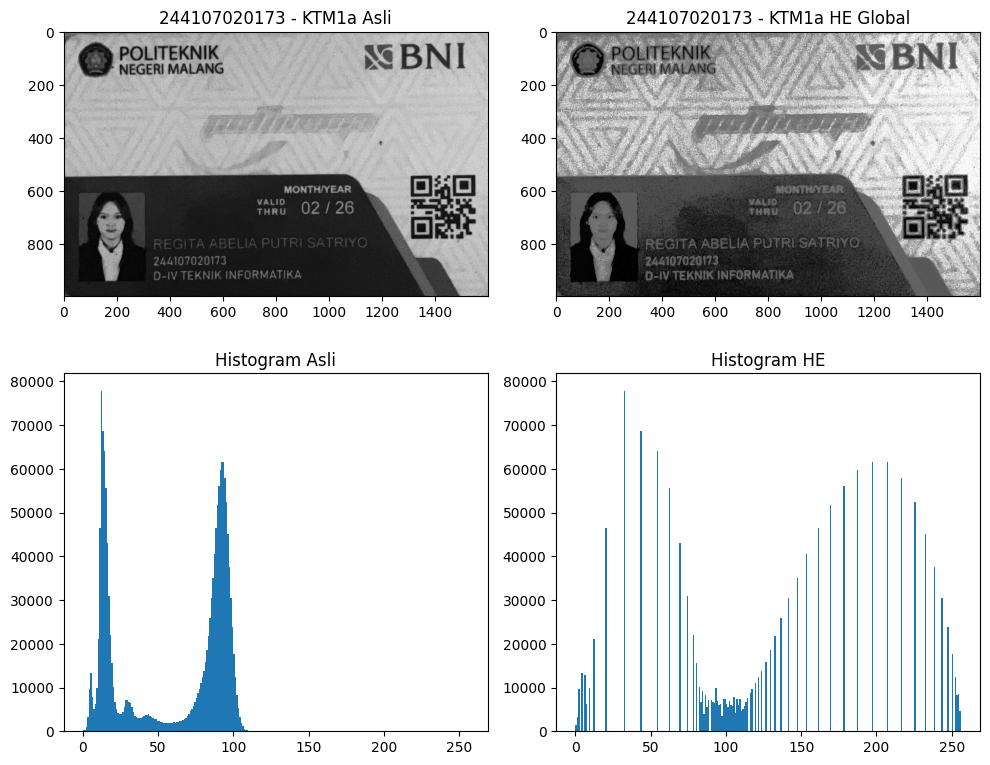

In [30]:
# Evaluasi PSNR pada KTM1a.jpg
def hitung_psnr(original, processed):
  mse = np.mean((original.astype(np.float64) - processed.astype(np.float64)) ** 2)
  if mse == 0:
    return float('inf')
  return 20 * np.log10(255.0 / np.sqrt(mse))


if os.path.exists(os.path.join(BASE, 'KTM1a.jpeg')):
  ktm_a = cv.imread(os.path.join(BASE, 'KTM1a.jpeg'), cv.IMREAD_GRAYSCALE)
  ktm_a_he = cv.equalizeHist(ktm_a)

  psnr_val = hitung_psnr(ktm_a, ktm_a_he)
  print(f'PSNR Antara Citra Asli dan Hasil Ekualisasi HE: {psnr_val:.2f} dB')

  fig, axs = plt.subplots(2, 2, figsize=(10, 8))
  axs[0, 0].imshow(ktm_a, cmap='gray')
  axs[0, 0].set_title(f'{NIM} - KTM1a Asli')
  axs[0, 1].imshow(ktm_a_he, cmap='gray')
  axs[0, 1].set_title(f'{NIM} - KTM1a HE Global')

  axs[1, 0].hist(ktm_a.ravel(), 256, [0, 256])
  axs[1, 0].set_title('Histogram Asli')
  axs[1, 1].hist(ktm_a_he.ravel(), 256, [0, 256])
  axs[1, 1].set_title('Histogram HE')
  plt.tight_layout()
  plt.show()

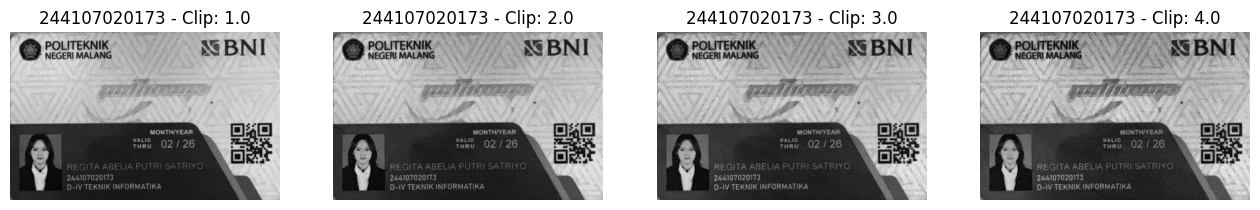

In [29]:
  if os.path.exists(os.path.join(BASE, 'KTM1a.jpeg')):
    ktm_a = cv.imread(os.path.join(BASE, 'KTM1a.jpeg'), cv.IMREAD_GRAYSCALE)

    # CLAHE dengan PARAM dari NIM
    clahe_user = cv.createCLAHE(
        clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile'])
    )
    ktm_clahe = clahe_user.apply(ktm_a)

    # Variasi ClipLimit
    clip_values = [1.0, 2.0, 3.0, 4.0]
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    for i, clip_v in enumerate(clip_values):
      c_obj = cv.createCLAHE(
          clipLimit=clip_v, tileGridSize=(PARAM['tile'], PARAM['tile'])
      )
      res = c_obj.apply(ktm_a)
      axs[i].imshow(res, cmap='gray')
      axs[i].set_title(f'{NIM} - Clip: {clip_v}')
      axs[i].axis('off')
    plt.show()

# **TUGAS PRAKTIKUM E3**

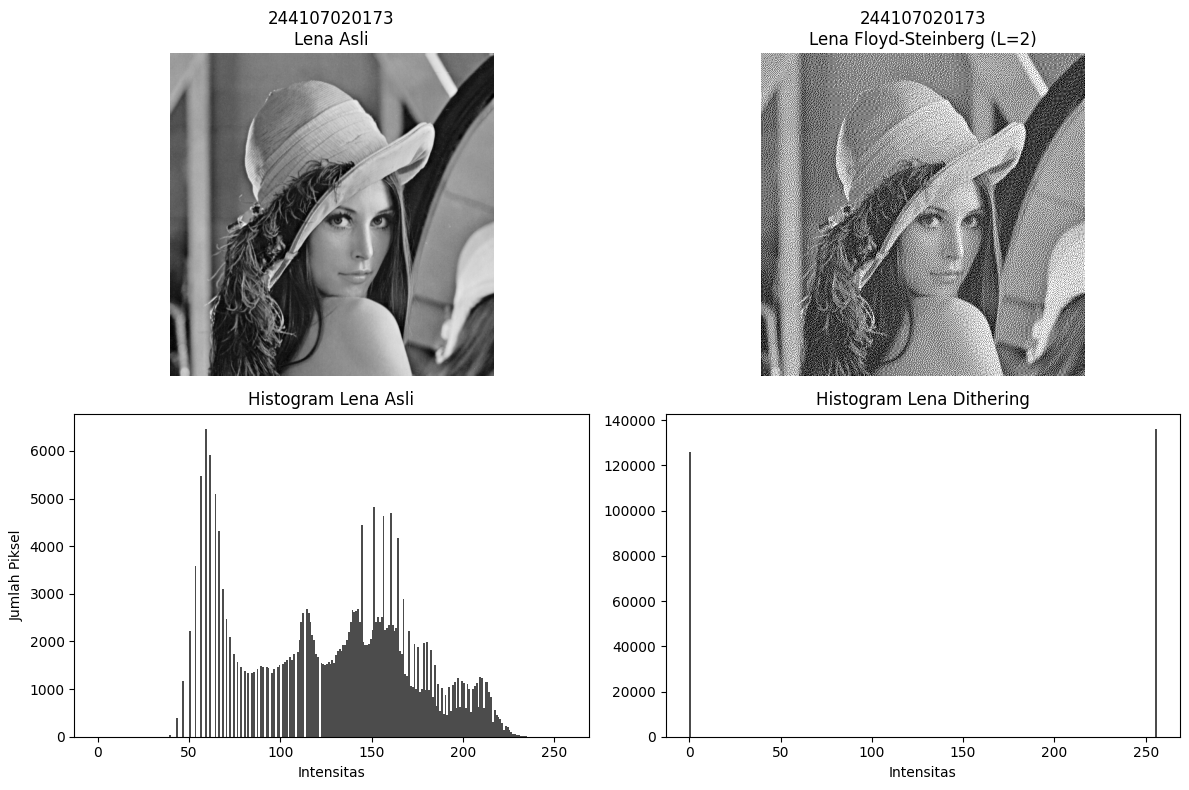

In [35]:
# NO 1
def floyd_steinberg(gray, L=2):
  img = gray.astype(np.float32).copy()
  step = 255.0 / (L - 1)
  H, W = img.shape

  for y in range(H):
    for x in range(W):
      old_val = img[y, x]
      new_val = np.round(old_val / step) * step
      img[y, x] = new_val
      err = old_val - new_val

      if x + 1 < W:
        img[y, x + 1] += err * 7 / 16
      if y + 1 < H:
        if x - 1 >= 0:
          img[y + 1, x - 1] += err * 3 / 16
        img[y + 1, x] += err * 5 / 16
        if x + 1 < W:
          img[y + 1, x + 1] += err * 1 / 16

  return np.clip(img, 0, 255).astype(np.uint8)

fpath_jpg = os.path.join(CONTOH, 'Lenna.png')
fpath_lc = os.path.join(CONTOH, 'lena_lc.jpg')
fpath_jpeg = os.path.join(CONTOH, 'Lenna.png')

if os.path.exists(fpath_jpg):
  fpath = fpath_jpg
elif os.path.exists(fpath_lc):
  fpath = fpath_lc
elif os.path.exists(fpath_jpeg):
  fpath = fpath_jpeg
else:
  fpath = None

if fpath:
  lena_g = cv.imread(fpath, cv.IMREAD_GRAYSCALE)

  if lena_g is not None:
    lena_dither = floyd_steinberg(lena_g, L=2)

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    axs[0, 0].imshow(lena_g, cmap='gray')
    axs[0, 0].set_title(f'{NIM}\nLena Asli')
    axs[0, 0].axis('off')

    axs[0, 1].imshow(lena_dither, cmap='gray')
    axs[0, 1].set_title(f'{NIM}\nLena Floyd-Steinberg (L=2)')
    axs[0, 1].axis('off')

    axs[1, 0].hist(lena_g.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
    axs[1, 0].set_title('Histogram Lena Asli')
    axs[1, 0].set_xlabel('Intensitas')
    axs[1, 0].set_ylabel('Jumlah Piksel')

    axs[1, 1].hist(lena_dither.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
    axs[1, 1].set_title('Histogram Lena Dithering')
    axs[1, 1].set_xlabel('Intensitas')

    plt.tight_layout()
    plt.show()
  else:
    print(f'Gagal membaca file dari path: {fpath}')
else:
  print(f'File lena (.jpg/.jpeg) TIDAK DITEMUKAN di lokasi: {CONTOH}')

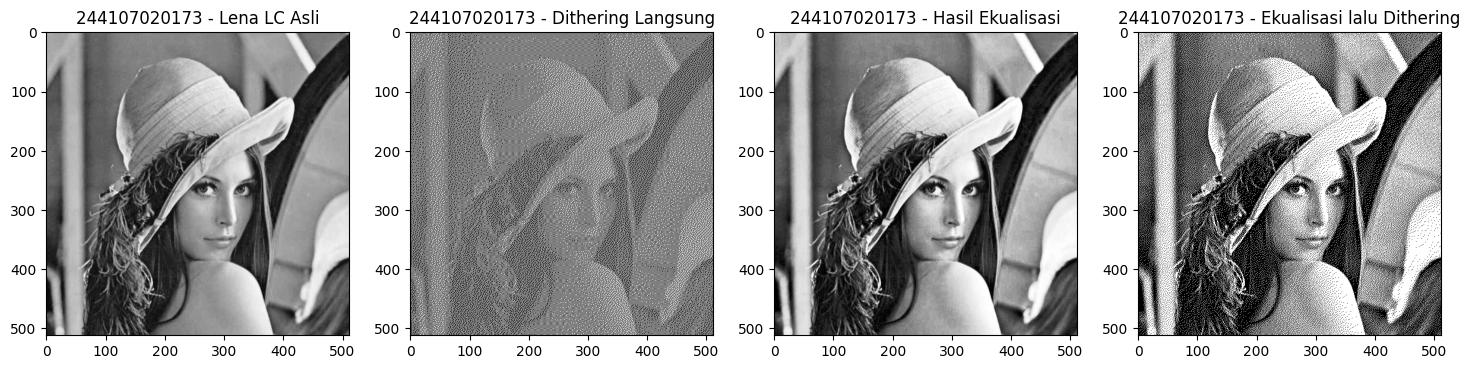

In [32]:
# NO 2
lena_lc = cv.imread(
    os.path.join(CONTOH, 'lena_lc.jpg'), cv.IMREAD_GRAYSCALE
)

lena_dither_direct = floyd_steinberg(lena_lc, L=2)

lena_eq = cv.equalizeHist(lena_lc)

lena_eq_dither = floyd_steinberg(lena_eq, L=2)

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
axs[0].imshow(lena_lc, cmap='gray')
axs[0].set_title(f'{NIM} - Lena LC Asli')
axs[1].imshow(lena_dither_direct, cmap='gray')
axs[1].set_title(f'{NIM} - Dithering Langsung')
axs[2].imshow(lena_eq, cmap='gray')
axs[2].set_title(f'{NIM} - Hasil Ekualisasi')
axs[3].imshow(lena_eq_dither, cmap='gray')
axs[3].set_title(f'{NIM} - Ekualisasi lalu Dithering')
plt.show()

if os.path.exists(os.path.join(BASE, 'KTM1a.jpg')):
  ktm_a = cv.imread(os.path.join(BASE, 'KTM1a.jpg'), cv.IMREAD_GRAYSCALE)
  ktm_d_direct = floyd_steinberg(ktm_a, L=PARAM['L'])
  ktm_eq = cv.equalizeHist(ktm_a)
  ktm_eq_dither = floyd_steinberg(ktm_eq, L=PARAM['L'])

  fig, axs = plt.subplots(1, 4, figsize=(18, 4))
  axs[0].imshow(ktm_a, cmap='gray')
  axs[0].set_title(f'{NIM} - KTM1a Asli')
  axs[1].imshow(ktm_d_direct, cmap='gray')
  axs[1].set_title(f'{NIM} - Dithering Langsung')
  axs[2].imshow(ktm_eq, cmap='gray')
  axs[2].set_title(f'{NIM} - Hasil Ekualisasi')
  axs[3].imshow(ktm_eq_dither, cmap='gray')
  axs[3].set_title(f'{NIM} - Ekualisasi lalu Dithering')
  plt.show()

Analisis:

Urutan Ekualisasi Lalu Dithering menghasilkan teks KTM yang jauh lebih jelas dan terbaca.   
- Alasan: Jika dithering dilakukan langsung pada citra ber-kontras rendah (seperti KTM1a.jpg), rentang dinamis piksel yang sangat sempit akan dikuantisasi secara buruk sehingga pola piksel bintik dithering menjadi homogen dan teks menyatu dengan latar belakang. Dengan meratakan/meregangkan kontras terlebih dahulu lewat ekualisasi histogram, perbedaan intensitas antara teks dan latar belakang menjadi lebih kontras, sehingga alokasi pola error diffusion menghasilkan tepi karakter teks yang tegas.